In [18]:
# Import Libraries

import gc
import sys
import tensorflow as tf
import tensorflow.keras as keras
import numpy as np
import matplotlib.pyplot as plt

import golois

print ("Python version", sys.version_info)
print ("Tensorflow version", tf.__version__)

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

def plot_learning_rate(lrs):
    plt.figure(figsize=(10, 5))
    plt.plot(lrs)
    plt.title('Learning Rate Evolution During Training')
    plt.xlabel('Batch')
    plt.ylabel('Learning Rate')
    plt.grid(True)
    plt.show()
    
def print_validation_results(model_results, epoch=100):
    for model, val, label, time in model_results:
        metrics = dict(zip(model.metrics_names, val))
        title = f"📊 Validation Results for {label}"
        if epoch is not None:
            title += f" — Epoch {epoch}"
        print(f"\n{title}:")
        for name, value in metrics.items():
            print(f"  - {name:<30}: {value:.4f}")
        print(f"  - Time: {time:.4f}")

def plot_result(history_dfs, val_dfs, labels, epochs=None):
    assert len(history_dfs) == len(labels)

    title = f"Epochs: {epochs}"

    fig = plt.figure(figsize=(18, 10))
    fig.suptitle(title, fontsize=14, fontweight='bold')
    gs = gridspec.GridSpec(2, 3)

    # --- Ligne 1 : 3 plots ---
    ax1 = fig.add_subplot(gs[0, 0])
    for df, val_df, label in zip(history_dfs, val_dfs, labels):
        ax1.plot(df['epoch'], df['loss'], label=f'{label} Train Loss')
        if val_df is not None:
            if 'val_policy_loss' in val_df.columns and 'val_value_loss' in val_df.columns:
                val_total_loss = val_df['val_policy_loss'] + val_df['val_value_loss']
                ax1.plot(val_df['epoch'], val_total_loss, 'o--', label=f'{label} Val Loss (recalculated)')
    ax1.set_title('Total Loss par Epoch')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Total Loss')
    ax1.legend()

    ax2 = fig.add_subplot(gs[0, 1])
    for df, val_df, label in zip(history_dfs, val_dfs, labels):
        if 'policy_loss' in df.columns:
            ax2.plot(df['epoch'], df['policy_loss'], label=f'{label} Train Policy Loss')
        if val_df is not None and 'val_policy_loss' in val_df.columns:
            ax2.plot(val_df['epoch'], val_df['val_policy_loss'], 'o--', label=f'{label} Val Policy Loss')
    ax2.set_title('Policy Loss par Epoch')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Policy Loss')
    ax2.legend()

    ax3 = fig.add_subplot(gs[0, 2])
    for df, val_df, label in zip(history_dfs, val_dfs, labels):
        if 'value_loss' in df.columns:
            ax3.plot(df['epoch'], df['value_loss'], label=f'{label} Train Value Loss')
        if val_df is not None and 'val_value_loss' in val_df.columns:
            ax3.plot(val_df['epoch'], val_df['val_value_loss'], 'o--', label=f'{label} Val Value Loss')
    ax3.set_title('Value Loss par Epoch')
    ax3.set_xlabel('Epoch')
    ax3.set_ylabel('Value Loss')
    ax3.legend()

    # --- Ligne 2 : 2 plots ---
    ax4 = fig.add_subplot(gs[1, 0])
    for df, label in zip(history_dfs, labels):
        if 'policy_categorical_accuracy' in df.columns:
            ax4.plot(df['epoch'], df['policy_categorical_accuracy'], label=f'{label} Train Policy Acc')
    ax4.set_title('Policy Accuracy par Epoch')
    ax4.set_xlabel('Epoch')
    ax4.set_ylabel('Categorical Accuracy')
    ax4.legend()

    ax5 = fig.add_subplot(gs[1, 1])
    for df, label in zip(history_dfs, labels):
        if 'value_mse' in df.columns:
            ax5.plot(df['epoch'], df['value_mse'], label=f'{label} Train Value MSE')
    ax5.set_title('Value MSE par Epoch')
    ax5.set_xlabel('Epoch')
    ax5.set_ylabel('MSE')
    ax5.legend()

    # Libérer la dernière case vide
    fig.delaxes(fig.add_subplot(gs[1, 2]))

    plt.tight_layout(rect=[0, 0, 1, 0.93])
    plt.show()


Python version sys.version_info(major=3, minor=9, micro=21, releaselevel='final', serial=0)
Tensorflow version 2.15.0


In [19]:
# v3.0.0 Full Revision - MobileNet Go Network

from tensorflow import keras
from keras import regularizers
from keras.models import Model
from keras.layers import (
    Input, Dense, Conv2D, GlobalAveragePooling2D, Dropout, Flatten,
    Activation, BatchNormalization, Add, Reshape, DepthwiseConv2D, Multiply,
    AveragePooling2D, Concatenate
)

# --- SE Block ---
def _se_block(input_tensor, filters, ratio=16, activation=keras.activations.swish):
    se = GlobalAveragePooling2D()(input_tensor)
    se = Reshape((1, 1, filters))(se)
    se = Dense(filters // ratio, activation=activation, use_bias=False,
               kernel_initializer='he_normal')(se)
    se = Dense(filters, activation='sigmoid', use_bias=False,
               kernel_initializer='glorot_normal')(se)
    return Multiply()([input_tensor, se])

# --- Convolution Block ---
def _conv_block(inputs, filters, kernel, activation=keras.activations.swish):
    x = Conv2D(filters, kernel, padding='same', kernel_regularizer=regularizers.l2(0.0001),
               use_bias=False, kernel_initializer='he_normal')(inputs)
    x = BatchNormalization(axis=-1)(x)
    x = Activation(activation)(x)
    return x

# --- MixDepthwise Block ---
def _mix_depthwise_conv(x):
    dw_3x3 = DepthwiseConv2D((3,3), padding='same', depthwise_regularizer=regularizers.l2(0.0001),
                             use_bias=False, depthwise_initializer='he_normal')(x)
    dw_5x5 = DepthwiseConv2D((5,5), padding='same', depthwise_regularizer=regularizers.l2(0.0001),
                             use_bias=False, depthwise_initializer='he_normal')(x)
    x = Concatenate(axis=-1)([dw_3x3, dw_5x5])
    x = BatchNormalization(axis=-1)(x)
    return x

# --- Bottleneck Block ---
def _bottleneck_block(inputs, filters, factor, se, activation=keras.activations.swish):
    expanded_filters = filters * factor

    x = _conv_block(inputs, filters=expanded_filters, kernel=(1, 1), activation=activation)
    x = _mix_depthwise_conv(x)
    x = _conv_block(x, filters=filters, kernel=(1, 1), activation=activation)

    if se:
        x = _se_block(x, filters, ratio=16, activation=activation)

    if inputs.shape[-1] != filters:
        inputs = _conv_block(inputs, filters=filters, kernel=(1,1), activation=activation)
    
    x = Add()([x, inputs])
    x = Activation(activation)(x)
    return x

# --- Full Model ---
def GoMobileNetv3(input_shape, filters, factor, block_num, se, activation=keras.activations.swish, drop_out_rate=0.3):
    inputs = Input(shape=input_shape)
    x = _conv_block(inputs, filters, (1, 1), activation=activation)

    for _ in range(block_num):
        x = _bottleneck_block(x, filters, factor, se, activation=activation)

    # --- Policy Head ---
    policy_head = _conv_block(x, filters=1, kernel=(1, 1), activation=activation)
    policy_head = Flatten()(policy_head)
    policy_head = Activation('softmax', name='policy')(policy_head)

    # --- Value Head with Spatial Average Pooling ---
    value_head = AveragePooling2D(pool_size=(2,2), strides=2, padding='same')(x)
    value_head = AveragePooling2D(pool_size=(2,2), strides=2, padding='same')(value_head)
    value_head = GlobalAveragePooling2D()(value_head)
    value_head = Dense(50, activation=activation, kernel_regularizer=regularizers.l2(0.0001),
                       kernel_initializer='he_normal')(value_head)
    value_head = Dropout(drop_out_rate)(value_head)
    value_head = Dense(1, activation='sigmoid', name='value',
                       kernel_regularizer=regularizers.l2(0.0001),
                       kernel_initializer='glorot_normal')(value_head)

    model = keras.Model(inputs=inputs, outputs=[policy_head, value_head])
    return model



In [20]:
# v2.0.2.1 Set SGD clipnorm=1.0

import time
import pandas as pd
import gc
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras import optimizers, backend as K
from tensorflow.keras.callbacks import Callback

# --- Example optimizer with CosineAnnealing ---
from tensorflow.keras.optimizers.schedules import CosineDecay
from tensorflow.keras import optimizers

class LrLogger(Callback):
    def __init__(self):
        super().__init__()
        self.lrs = []

    def on_train_batch_end(self, batch, logs=None):
        # Récupère le learning rate de l'optimizer
        lr_schedule = self.model.optimizer.learning_rate

        if hasattr(lr_schedule, '__call__'):
            # Si c'est un scheduler (comme CosineDecay), évalue-le dynamiquement
            lr = float(K.get_value(lr_schedule(self.model.optimizer.iterations)))
        else:
            # Sinon (simple Variable/float), récupère la valeur
            lr = float(K.get_value(lr_schedule))

        self.lrs.append(lr)

def get_cosine_annealing_optimizer(initial_lr=0.05, decay_steps=10000, alpha=0.001):
    cosine_lr = CosineDecay(
        initial_learning_rate=initial_lr,
        decay_steps=decay_steps,
        alpha=alpha
    )
    optimizer = optimizers.legacy.SGD(learning_rate=cosine_lr, momentum=0.9, nesterov=True, clipnorm=1.0)
    
    return optimizer

def train_model(model, batch=32, policy_weight=1.0, value_weight=1.0, epochs=100, N=10000):
    start_time = time.time()
    
    # Configuration
    planes = 31
    moves = 361

    input_data = np.random.randint(2, size=(N, 19, 19, planes))
    input_data = input_data.astype ('float32')

    policy = np.random.randint(moves, size=(N,))
    policy = keras.utils.to_categorical (policy)

    value = np.random.randint(2, size=(N,))
    value = value.astype ('float32')

    end = np.random.randint(2, size=(N, 19, 19, 2))
    end = end.astype ('float32')

    groups = np.zeros((N, 19, 19, 1))
    groups = groups.astype ('float32')

    # Get Validation Data

    print ("getValidation", flush = True)
    golois.getValidation (input_data, policy, value, end)

    # Variable globale pour suivre la meilleure perte
    best_val_loss = float('inf')

    logger = LrLogger()

    batches_per_epoch = N // batch
    optimizer = get_cosine_annealing_optimizer(initial_lr=0.05, decay_steps=batches_per_epoch * epochs)
    
    model.compile(
        optimizer=optimizer,
        loss={'policy': 'categorical_crossentropy', 'value': 'binary_crossentropy'},
        loss_weights={'policy': policy_weight, 'value': value_weight},
        metrics={'policy': 'categorical_accuracy', 'value': 'mse'}
    )

    all_history = []
    val_loss_history = []
    

    for i in range(1, epochs + 1):
        epoch_start_time = time.time()

        # Récupération des données
        golois.getBatch(input_data, policy, value, end, groups, i * N)

        history = model.fit(
            input_data,
            {'policy': policy, 'value': value},
            epochs=1,
            batch_size=batch,
            verbose=0,
            callbacks=[logger]
        )

        metrics = {key: val[0] for key, val in history.history.items()}
        metrics['epoch'] = i
        all_history.append(metrics)

        
        if i % 5 == 0:
            gc.collect()

        if i % 10 == 0:    
            # Évaluation du modèle sur les données de validation
            golois.getValidation(input_data, policy, value, end)
            val = model.evaluate(input_data, [policy, value], verbose=0, batch_size=batch)
            val_loss_history.append({
                'epoch': i,
                'val_policy_loss': val[1],
                'val_value_loss': val[2]
            })
            print(f"Validation: policy_loss={val[1]:.4f}, value_loss={val[2]:.4f}")
            
            #current_val_loss = val[0]  # loss globale
            #if current_val_loss < best_val_loss:
            #    print(f"Saving new best model at epoch {i} with val_loss={current_val_loss:.4f}")

                # Format propre du nom de fichier
            #    filename = f"best_model_epoch{i}_val{current_val_loss:.4f}.h5"
            #    model.save(filename)

            #    best_val_loss = current_val_loss

        # Affichage des métriques
        print(
            f"Epoch {i}/{epochs}: time={time.time() - epoch_start_time:.2f}s, "
            f"loss={metrics['loss']:.4f}, "
            f"policy_loss={metrics['policy_loss']:.4f}, "
            f"value_loss={metrics['value_loss']:.4f}, "
            f"policy_categorical_accuracy={metrics['policy_categorical_accuracy']:.4f}, "
            f"value_mse={metrics['value_mse']:.4f}"
        )

    total_time = time.time() - start_time
    return val, pd.DataFrame(all_history), pd.DataFrame(val_loss_history), total_time, logger.lrs

In [21]:
# Modèle 1 : GoMobileNetv2 (64,4,3) 
# - Nesterov  True 
# - SE True
# - Cyclyc lR
# - Batch size 32
# - Policy weight 1.0
# - Value weight 1.0

model = GoMobileNetv3((19,19,31), 64, 4, 2, True, activation=keras.activations.swish, drop_out_rate=0.3)
model.summary()

for layer in model.layers:
    if hasattr(layer, 'activation'):
        print(f"{layer.name}: activation = {layer.activation.__name__}")


Model: "model_2"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_3 (InputLayer)        [(None, 19, 19, 31)]         0         []                            
                                                                                                  
 conv2d_12 (Conv2D)          (None, 19, 19, 64)           1984      ['input_3[0][0]']             
                                                                                                  
 batch_normalization_16 (Ba  (None, 19, 19, 64)           256       ['conv2d_12[0][0]']           
 tchNormalization)                                                                                
                                                                                                  
 activation_16 (Activation)  (None, 19, 19, 64)           0         ['batch_normalization_16

getValidation


r.shape = (10000, 19, 19, 31)
nbExamples = 10000


Epoch 1/250: time=17.69s, loss=4.5255, policy_loss=3.6767, value_loss=0.6916, policy_categorical_accuracy=0.2196, value_mse=0.1198
Epoch 2/250: time=15.99s, loss=4.0032, policy_loss=3.1501, value_loss=0.6910, policy_categorical_accuracy=0.2873, value_mse=0.1217
Epoch 3/250: time=16.25s, loss=3.8805, policy_loss=3.0270, value_loss=0.6893, policy_categorical_accuracy=0.3050, value_mse=0.1183
Epoch 4/250: time=16.46s, loss=3.7909, policy_loss=2.9377, value_loss=0.6884, policy_categorical_accuracy=0.3190, value_mse=0.1198
Epoch 5/250: time=17.34s, loss=3.7531, policy_loss=2.8996, value_loss=0.6893, policy_categorical_accuracy=0.3266, value_mse=0.1207
Epoch 6/250: time=18.12s, loss=3.7351, policy_loss=2.8825, value_loss=0.6892, policy_categorical_accuracy=0.3240, value_mse=0.1188
Epoch 7/250: time=17.94s, loss=3.6919, policy_loss=2.8407, value_loss=0.6886, policy_categorical_accuracy=0.3259, value_mse=0.1187
Epoch 8/250: time=17.91s, loss=3.6969, policy_loss=2.8468, value_loss=0.6888, polic

r.shape = (10000, 19, 19, 31)
nbExamples = 10000


Validation: policy_loss=2.8226, value_loss=0.6864
Epoch 10/250: time=31.50s, loss=3.6281, policy_loss=2.7809, value_loss=0.6886, policy_categorical_accuracy=0.3396, value_mse=0.1187
Epoch 11/250: time=17.00s, loss=3.6196, policy_loss=2.7744, value_loss=0.6877, policy_categorical_accuracy=0.3468, value_mse=0.1193
Epoch 12/250: time=16.87s, loss=3.6447, policy_loss=2.7995, value_loss=0.6887, policy_categorical_accuracy=0.3380, value_mse=0.1196
Epoch 13/250: time=16.74s, loss=3.6139, policy_loss=2.7722, value_loss=0.6866, policy_categorical_accuracy=0.3451, value_mse=0.1176
Epoch 14/250: time=17.15s, loss=3.6360, policy_loss=2.7935, value_loss=0.6884, policy_categorical_accuracy=0.3312, value_mse=0.1181
Epoch 15/250: time=17.29s, loss=3.6181, policy_loss=2.7793, value_loss=0.6860, policy_categorical_accuracy=0.3400, value_mse=0.1195
Epoch 16/250: time=17.25s, loss=3.5977, policy_loss=2.7590, value_loss=0.6871, policy_categorical_accuracy=0.3433, value_mse=0.1187
Epoch 17/250: time=16.93s,

...

Validation: policy_loss=2.3214, value_loss=0.6591
Epoch 230/250: time=31.48s, loss=3.0912, policy_loss=2.3352, value_loss=0.6605, policy_categorical_accuracy=0.4048, value_mse=0.1076
Epoch 231/250: time=18.06s, loss=3.0672, policy_loss=2.3097, value_loss=0.6621, policy_categorical_accuracy=0.4128, value_mse=0.1059
Epoch 232/250: time=17.77s, loss=3.0908, policy_loss=2.3365, value_loss=0.6590, policy_categorical_accuracy=0.4031, value_mse=0.1044
Epoch 233/250: time=17.99s, loss=3.0688, policy_loss=2.3150, value_loss=0.6585, policy_categorical_accuracy=0.4127, value_mse=0.1072
Epoch 234/250: time=17.91s, loss=3.0868, policy_loss=2.3256, value_loss=0.6660, policy_categorical_accuracy=0.4136, value_mse=0.1079
Epoch 235/250: time=18.10s, loss=3.0733, policy_loss=2.3109, value_loss=0.6673, policy_categorical_accuracy=0.4070, value_mse=0.1090
Epoch 236/250: time=17.83s, loss=3.0890, policy_loss=2.3318, value_loss=0.6621, policy_categorical_accuracy=0.4059, value_mse=0.1073
Epoch 237/250: time

r.shape = (10000, 19, 19, 31)
nbExamples = 10000


Validation: policy_loss=2.3164, value_loss=0.6593
Epoch 240/250: time=32.03s, loss=3.0508, policy_loss=2.2947, value_loss=0.6611, policy_categorical_accuracy=0.4146, value_mse=0.1075
Epoch 241/250: time=17.84s, loss=3.0899, policy_loss=2.3334, value_loss=0.6615, policy_categorical_accuracy=0.4041, value_mse=0.1061
Epoch 242/250: time=17.77s, loss=3.0899, policy_loss=2.3316, value_loss=0.6633, policy_categorical_accuracy=0.4024, value_mse=0.1084
Epoch 243/250: time=17.76s, loss=3.1155, policy_loss=2.3546, value_loss=0.6660, policy_categorical_accuracy=0.3965, value_mse=0.1074
Epoch 244/250: time=17.85s, loss=3.0777, policy_loss=2.3210, value_loss=0.6618, policy_categorical_accuracy=0.4025, value_mse=0.1086
Epoch 245/250: time=17.92s, loss=3.1008, policy_loss=2.3454, value_loss=0.6605, policy_categorical_accuracy=0.3972, value_mse=0.1063
Epoch 246/250: time=17.99s, loss=3.0902, policy_loss=2.3327, value_loss=0.6627, policy_categorical_accuracy=0.3992, value_mse=0.1074
Epoch 247/250: time

r.shape = (10000, 19, 19, 31)
nbExamples = 10000


Validation: policy_loss=2.3152, value_loss=0.6585
Epoch 250/250: time=32.18s, loss=3.0952, policy_loss=2.3362, value_loss=0.6642, policy_categorical_accuracy=0.4076, value_mse=0.1085

📊 Validation Results for Mon Model — Epoch 250:
  - loss                          : 3.0686
  - policy_loss                   : 2.3152
  - value_loss                    : 0.6585
  - policy_categorical_accuracy   : 0.4081
  - value_mse                     : 0.1059
  - Time: 5488.9731


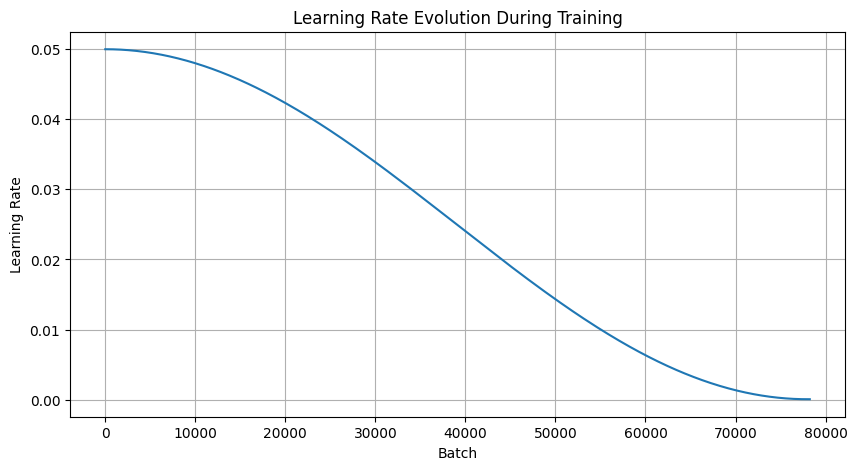

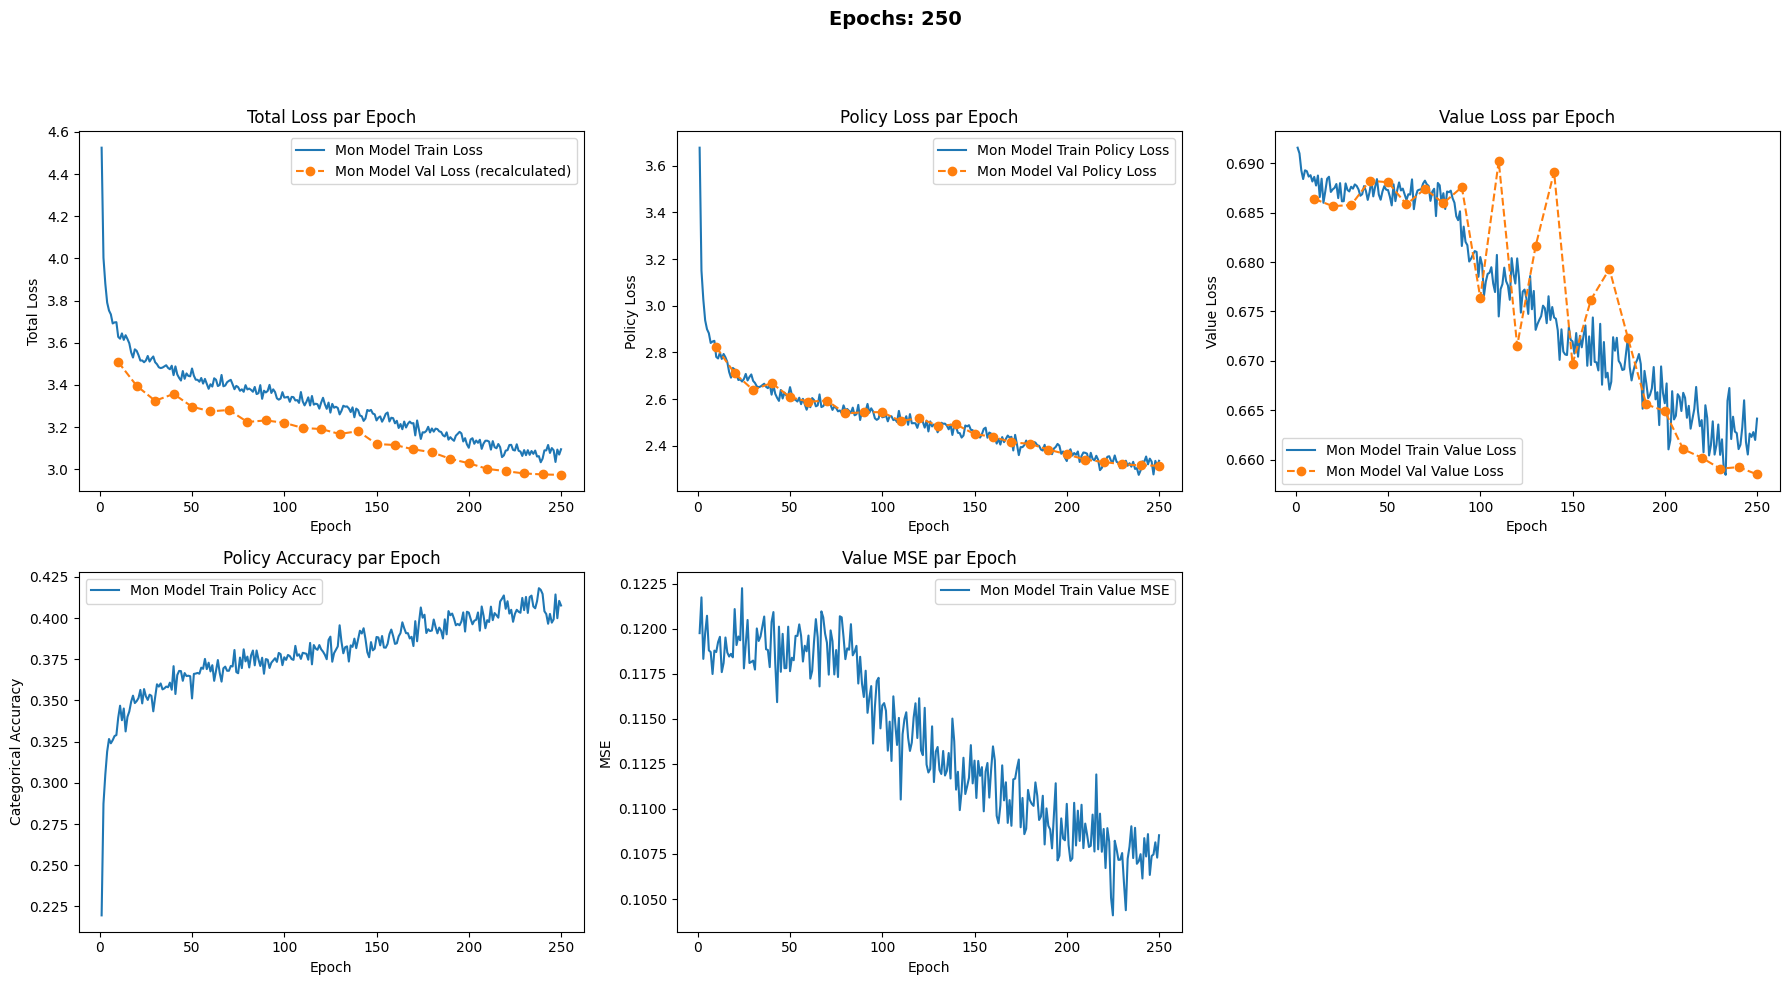

In [22]:
epochs=250

val, all_history, val_loss_history, total_time, lrs = train_model(
    model, 
    batch=32, 
    policy_weight=1.0, 
    value_weight=1.0, 
    epochs=epochs,
    N=10000
)

# Affichage des résultats
results = [
    (model, val, "Mon Model", total_time)
]
print_validation_results(results, epoch=epochs)

# Affichage de l'évolution du taux d'apprentissage
plot_learning_rate(lrs)

# Affichage des courbes comparatives
plot_result(
    history_dfs=[all_history], 
    val_dfs=[val_loss_history], 
    labels=["Mon Model"], 
    epochs=epochs
)